# Architectures

`probjax.nn.nets` holds the plain architectures — pure `flax.nnx` modules with no training
semantics attached. Generative wrappers (diffusion, flow matching, normalizing flows) live
in `probjax.nn.generative` and *use* these as backbones.

`Transformer` gets its own notebook (`transformer.ipynb`). This one is a tour of the rest,
organised by the structure each one assumes about its input:

| input is… | module |
|---|---|
| a vector | `MLP`, `ResNet` |
| a vector with an ordering | `MaskedMLP` |
| a set | `DeepSet` |
| a vector plus a time | `TimeMLP` |
| a grid | `UNet` |
| a sequence | `LRUModel`, and the recurrent cells |

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn.nets import (
    MLP,
    DeepSet,
    LRUModel,
    MaskedMLP,
    ResNet,
    Sequential,
    TimeMLP,
    UNet,
)

jax.config.update("jax_platform_name", "cpu")
x = jax.random.normal(jax.random.key(0), (4, 8))

## `MLP` and `ResNet`

`MLP` takes the full list of widths — input first, output last — so the shape of the
network is one readable argument. `ResNet` instead takes `in_features`/`out_features` and a
uniform hidden width, and wires residual connections between the hidden blocks, which is
what lets you go deep without the gradient signal dying.

Both accept `context_dim` for conditioning, fused the same way as in `Transformer`.

In [2]:
mlp = MLP([8, 64, 64, 2], rngs=nnx.Rngs(0))
resnet = ResNet(8, 2, hidden_dim=64, num_hidden_layers=3, rngs=nnx.Rngs(0))
print("MLP   ", x.shape, "->", mlp(x).shape)
print("ResNet", x.shape, "->", resnet(x).shape)

conditioned = MLP([8, 64, 2], context_dim=3, rngs=nnx.Rngs(0))
context = jax.random.normal(jax.random.key(1), (4, 3))
print("MLP with context:", conditioned(x, context=context).shape)

# Sequential chains any callables, including plain functions.
print("Sequential:", Sequential(mlp, jax.nn.tanh)(x).shape)

MLP    (4, 8) -> (4, 2)
ResNet (4, 8) -> (4, 2)


MLP with context: (4, 2)
Sequential: (4, 2)


## `MaskedMLP` — autoregressive structure

Zero out entries of each weight matrix and the network's *Jacobian* inherits the pattern.
Choose the masks so that output $i$ can only reach inputs $< i$ and you get an
autoregressive model in one forward pass instead of $d$ — this is MADE, and it is the
conditioner inside every autoregressive flow in `probjax.nn.generative.flows`.

The construction assigns each unit a **degree**. A connection is allowed only when it does
not let information flow backwards through the ordering:

strictly lower triangular: True


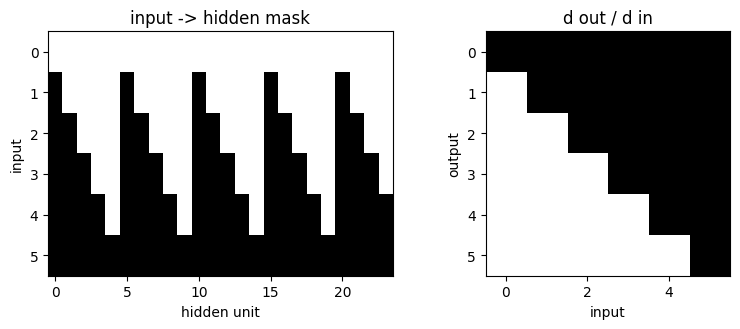

In [3]:
DIM, HIDDEN = 6, 24

input_degrees = jnp.arange(1, DIM + 1)
hidden_degrees = jnp.arange(HIDDEN) % (DIM - 1) + 1
output_degrees = jnp.arange(1, DIM + 1)

masks = [
    hidden_degrees[None, :] >= input_degrees[:, None],   # input  -> hidden
    hidden_degrees[None, :] >= hidden_degrees[:, None],  # hidden -> hidden
    output_degrees[None, :] > hidden_degrees[:, None],   # hidden -> output  (strict!)
]
made = MaskedMLP([DIM, HIDDEN, HIDDEN, DIM], masks, rngs=nnx.Rngs(0))

jacobian = jax.jacobian(made)(jax.random.normal(jax.random.key(0), (DIM,)))
print("strictly lower triangular:", bool(jnp.abs(jnp.triu(jacobian)).max() < 1e-9))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
axes[0].imshow(masks[0], cmap="Greys_r", aspect="auto")
axes[0].set(title="input -> hidden mask", xlabel="hidden unit", ylabel="input")
axes[1].imshow(jnp.abs(jacobian) > 1e-9, cmap="Greys_r")
axes[1].set(title="d out / d in", xlabel="input", ylabel="output")
fig.tight_layout()

The last mask uses a strict `>`: output $i$ must *not* see input $i$, only what came
before it. Using `>=` there is the classic MADE bug — the density it defines is degenerate,
and nothing about the loss curve will tell you.

## `DeepSet` — permutation invariance

For unordered inputs. Embed each element with `phi`, reduce over the set axis, map the
result with `rho`. Because the reduction is a sum, the output cannot depend on the order,
and the same weights accept any set size.

In [4]:
deep_set = DeepSet(
    phi=MLP([3, 32, 32], rngs=nnx.Rngs(0)),
    rho=MLP([32, 32, 2], rngs=nnx.Rngs(1)),
    rngs=nnx.Rngs(2),
)

points = jax.random.normal(jax.random.key(1), (4, 25, 3))
perm = jax.random.permutation(jax.random.key(2), 25)
print("permutation invariant:", bool(jnp.allclose(deep_set(points), deep_set(points[:, perm]), atol=1e-5)))
print("25 elements ->", deep_set(points).shape, " 10 elements ->", deep_set(points[:, :10]).shape)

permutation invariant: True
25 elements -> (4, 2)  10 elements -> (4, 2)


## `TimeMLP` — conditioning on a continuous time

Diffusion and flow-matching models need a network of $(t, x)$ where $t$ is a scalar noise
level. Feeding a raw float into an MLP works badly: the network has to learn a
high-frequency function of it from scratch. `TimeMLP` embeds `t` with random Fourier
features first, then conditions the trunk on that embedding.

It is the default backbone for the 2-D examples in `examples/nn/generative/`.

TimeMLP(t, x): (4, 8)


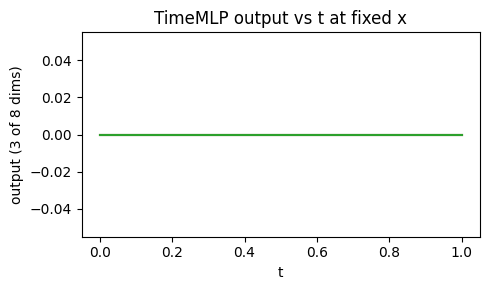

In [5]:
time_mlp = TimeMLP(8, hidden_dim=64, depth=2, rngs=nnx.Rngs(0))
t = jnp.full((4, 1), 0.3)
print("TimeMLP(t, x):", time_mlp(t, x).shape)

# The time dependence is smooth but not trivially linear -- that is the point of the
# Fourier embedding.
ts = jnp.linspace(0, 1, 200)[:, None]
single = jnp.zeros((200, 8))
plt.figure(figsize=(5, 3))
plt.plot(ts[:, 0], time_mlp(ts, single)[:, :3])
plt.xlabel("t")
plt.ylabel("output (3 of 8 dims)")
plt.title("TimeMLP output vs t at fixed x")
plt.tight_layout()

## `UNet` — grids

Downsample, process, upsample, with skip connections carrying the fine detail past the
bottleneck. `out_features` lists the channel widths per stage, and each stage halves the
resolution. `use_attention` turns on `SpatialSelfAttention` at chosen stages.

**Kernel sizes decide the rank.** An int means one spatial dimension (a 1-D U-Net for
signals); a tuple of two means two (an image U-Net). The default is `kernel_size=4`, which
is an int, so the default `UNet` is 1-D — pass tuples if the input is an image.

In [6]:
signal_unet = UNet(1, [32, 64], rngs=nnx.Rngs(0))
signal = jax.random.normal(jax.random.key(2), (2, 64, 1))
print("1-D UNet:", signal.shape, "->", signal_unet(signal).shape)

image_unet = UNet(1, [32, 64], kernel_size=(4, 4), kernel_size_resnet=(3, 3), rngs=nnx.Rngs(0))
image = jax.random.normal(jax.random.key(2), (2, 32, 32, 1))
print("2-D UNet:", image.shape, "->", image_unet(image).shape)

params = sum(p.size for _, p in nnx.to_flat_state(nnx.state(image_unet, nnx.Param)))
print(f"image UNet parameters: {params:,}")

1-D UNet: (2, 64, 1) -> (2, 64, 1)


2-D UNet: (2, 32, 32, 1) -> (2, 32, 32, 1)
image UNet parameters: 469,248


## Sequence models

`LRUModel` stacks linear recurrent units. Unlike attention it is $O(T)$ in sequence length
rather than $O(T^2)$, and unlike a classic RNN the recurrence is linear, so the whole
sequence is computed with a parallel scan instead of a sequential loop.

`bidirectional` **alternates direction between layers** — even layers run forwards, odd
layers backwards. With a single layer it therefore does nothing at all; you need at least
two for it to have any effect. The Jacobian shows this directly:

In [7]:
sequence = jax.random.normal(jax.random.key(3), (2, 40, 16))
print("LRUModel:", sequence.shape, "->", LRUModel(16, 32, 4, 2, rngs=nnx.Rngs(0))(sequence).shape)


def leak_above_diagonal(num_layers, bidirectional):
    model = LRUModel(1, 16, 1, num_layers, bidirectional=bidirectional, rngs=nnx.Rngs(0))
    jac = jax.jacobian(lambda s: model(s.reshape(1, -1, 1))[0, :, 0])(jnp.ones(12))
    return float(jnp.abs(jnp.triu(jac, 1)).max())


for layers in (1, 2):
    for bidirectional in (False, True):
        leak = leak_above_diagonal(layers, bidirectional)
        kind = "sees the future" if leak > 1e-6 else "strictly causal"
        print(f"num_layers={layers} bidirectional={bidirectional!s:<5} -> {kind}")

LRUModel: (2, 40, 16) -> (2, 40, 4)


num_layers=1 bidirectional=False -> strictly causal
num_layers=1 bidirectional=True  -> strictly causal
num_layers=2 bidirectional=False -> strictly causal


num_layers=2 bidirectional=True  -> sees the future


### Recurrent cells

The individual cells are usable on their own, all with the same
`(batch, seq, model_dim) -> (batch, seq, model_dim)` signature:

- **`LRUCell`** — the diagonal linear recurrence used by `LRUModel`. Pure JAX, runs
  anywhere.
- **`MambaCell`** — selective state space (S6), where the recurrence weights depend on the
  input.
- **`SSDCell`** — the Mamba-2 state-space-dual formulation, with a fused forward and a
  hand-written backward pass.

`MambaCell` and `SSDCell` are Pallas kernels and **require a GPU or TPU** — on CPU they
raise rather than silently falling back, which is the honest behaviour. Only `LRUCell` runs
in this notebook:

In [8]:
from probjax.nn.layers.lru import LRUCell, MambaCell, SSDCell

print("LRUCell:", LRUCell(16, nnx.Rngs(0))(sequence).shape)

for name, cell_cls in [("MambaCell", MambaCell), ("SSDCell", SSDCell)]:
    try:
        print(f"{name}:", cell_cls(16, nnx.Rngs(0))(sequence).shape)
    except RuntimeError as error:
        print(f"{name}: {error}")

LRUCell: (2, 40, 16)
MambaCell: compute_mamba_scan requires an accelerator backend.


SSDCell: ssd requires an accelerator backend.


## Where to go next

- `attention.ipynb`, `transformer.ipynb` — the attention family.
- `sharding.ipynb` — running any of these across devices.
- `examples/nn/generative/` — these architectures as backbones for diffusion, flow
  matching and normalizing flows.